<a href="https://colab.research.google.com/github/Jeatiejade/TS_Academy_Capstone_Project/blob/main/Life_Expectancy__Group18__final_Tasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Capstone Project

Predicting Life Expectancy Using Socioeconomic and Health Indicators


**Objective**

This project aims to build regression models to predict life expectancy using socioeconomic and health related indicators. The goal is to identify the key factors influencing life expectancy and compare the performance of Linear Regression and Random Forest models.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Importing Required Libraries**


In this section, we import the necessary Python libraries for data handling, visualization, preprocessing, modeling, and evaluation. These tools will support the entire analysis workflow.

In [ ]:
# Data handling
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and model tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Multicollinearity check
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

**Data Loading and Initial Inspection**

The dataset is loaded into a pandas DataFrame for analysis. Initial inspection is performed to verify that the file was successfully imported and to preview the structure of the data.

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Life Expectancy Data.csv")

df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   float64
 2   Status                           2938 non-null   float64
 3   Life_expectancy                  2938 non-null   float64
 4   Adult_Mortality                  2938 non-null   float64
 5   infant_deaths                    2938 non-null   float64
 6   Alcohol                          2938 non-null   float64
 7   percentage_expenditure           2938 non-null   float64
 8   Hepatitis_B                      2938 non-null   float64
 9   Measles                          2938 non-null   float64
 10  BMI                              2938 non-null   float64
 11  under-five_deaths                2938 non-null   float64
 12  Polio               

In [ ]:
# Summary statistics for numerical columns
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [ ]:
# Summary statistics for non-numerical columns
df.describe(include = ["object"])

,Country,Status
count,2938,2938
unique,193,2
top,Afghanistan,Developing
freq,16,2426


In [ ]:
df.nunique()

,0
Country,193
Year,16
Status,2
Life expectancy,362
Adult Mortality,425
infant deaths,209
Alcohol,1076
percentage expenditure,2328
Hepatitis B,87
Measles,958


**Cleaning Column Names**

The original dataset contains column names with extra spaces and inconsistent formatting. To improve readability and avoid potential errors during modeling, column names are cleaned by removing leading and trailing spaces and replacing internal spaces with underscores.

This ensures consistent naming conventions across all variables.

In [ ]:
# Remove leading and trailing spaces
df.columns = df.columns.str.strip()

# Replace internal spaces with underscores
df.columns = df.columns.str.replace(" ", "_")

df.columns

Index(['Country', 'Year', 'Status', 'Life_expectancy', 'Adult_Mortality',
       'infant_deaths', 'Alcohol', 'percentage_expenditure', 'Hepatitis_B',
       'Measles', 'BMI', 'under-five_deaths', 'Polio', 'Total_expenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness__1-19_years',
       'thinness_5-9_years', 'Income_composition_of_resources', 'Schooling'],
      dtype='object')

**Handling Missing Values**

Before building any predictive model, it is important to address missing values in the dataset. Several numeric variables contain missing observations. Dropping these rows would significantly reduce the dataset size and potentially bias the results.

To preserve the dataset while maintaining stability, missing numeric values are imputed using the median of each column. Median imputation is chosen because some economic indicators such as GDP and Population may have skewed distributions, making the median more robust than the mean.

In [ ]:
# Check missing values
df.isnull().sum().sort_values(ascending=False)

,0
Population,652
Hepatitis_B,553
GDP,448
Total_expenditure,226
Alcohol,194
Income_composition_of_resources,167
Schooling,163
thinness__1-19_years,34
thinness_5-9_years,34
BMI,34


**Encoding Categorical Variables**

The Status column indicates whether a country is classified as developed or developing. Since regression models require numeric inputs, this categorical variable is converted into binary format:

Developing → 0
Developed → 1

This allows the model to incorporate development status as a predictive feature.

In [ ]:
df["Status"] = df["Status"].map({"Developing": 0, "Developed": 1})

df["Status"].head()

,Status
0,0
1,0
2,0
3,0
4,0


## Exploratory Data Analysis

Exploratory Data Analysis is conducted to understand the distribution of the features, target variable and examine relationships between predictors and life expectancy.

A histogram is used to observe the distribution of life expectancy. A correlation heatmap is generated to identify variables that are strongly positively or negatively associated with the target variable.

Understanding these relationships helps guide feature interpretation and model development.

**Target Variable (Life Expectancy) Analysis**

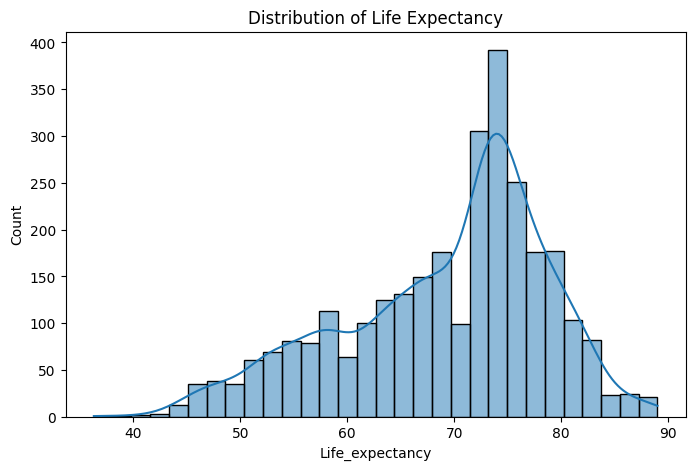

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Life_expectancy"], bins=30, kde=True)
plt.title("Distribution of Life Expectancy")
plt.show()

**Distribution Interpretation**

The distribution of life expectancy appears approximately normal with a slight skew. Most values fall between 60 and 80 years. The absence of extreme outliers suggests that the target variable is suitable for regression modeling, as the model assumes normal distriution.

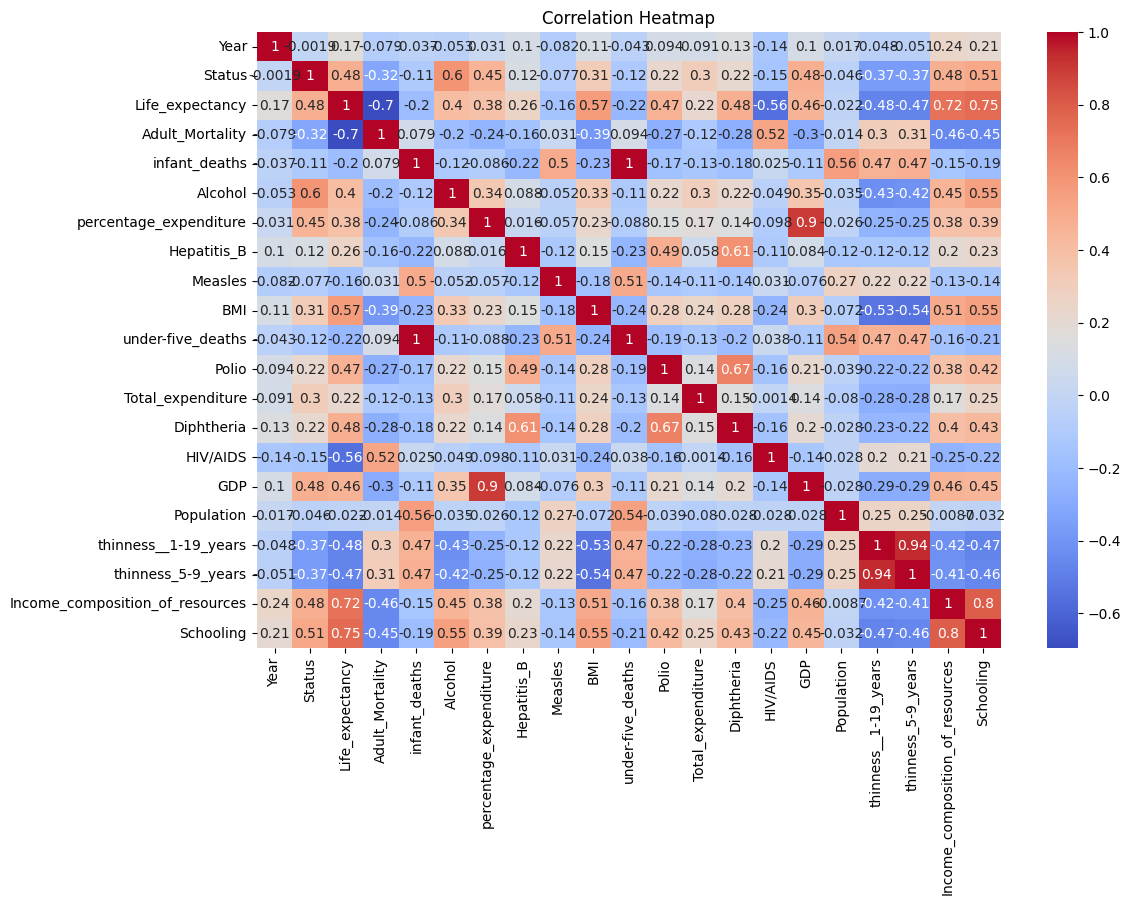

In [ ]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot= True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
numeric_df.columns

Index(['Year', 'Status', 'Life_expectancy', 'Adult_Mortality', 'infant_deaths',
       'Alcohol', 'percentage_expenditure', 'Hepatitis_B', 'Measles', 'BMI',
       'under-five_deaths', 'Polio', 'Total_expenditure', 'Diphtheria',
       'HIV/AIDS', 'GDP', 'Population', 'thinness__1-19_years',
       'thinness_5-9_years', 'Income_composition_of_resources', 'Schooling'],
      dtype='object')

**Correlation Interpretation**

The heatmap shows that Life_expectancy is strongly positively correlated with Schooling, Income_composition_of_resources, and GDP. This suggests that economic development and education levels are important predictors of life expectancy.

Strong negative correlations are observed with Adult_Mortality and HIV/AIDS, indicating that higher mortality rates and disease prevalence significantly reduce life expectancy.

The heatmap also points out multicolinearity between certain pairs of features, namely;
* under_five_deaths / infant_deaths = 1
* GDP / percentage_expenditure = 0.9
* thinness_1-19_years / thinness_5-9_years = 0.94

These can be potentially be a problem to our linear regression model as high multicollinearity causes unstable coefficients, inflated standard errors and interpretation difficulty.
Two features with correlation value ~ 1, indicate high positive correlation i.e that they move almost perfectly together and they feed the model the same information. Hence the occurence of redundant features.

To effeciently handle this, for each feature in the pair we compare correlation with the target(Life_expectancy). We then keep the feature that has a stronger relationship with target, is more interpretable and makes more domain sense.

**Features
Analysis**

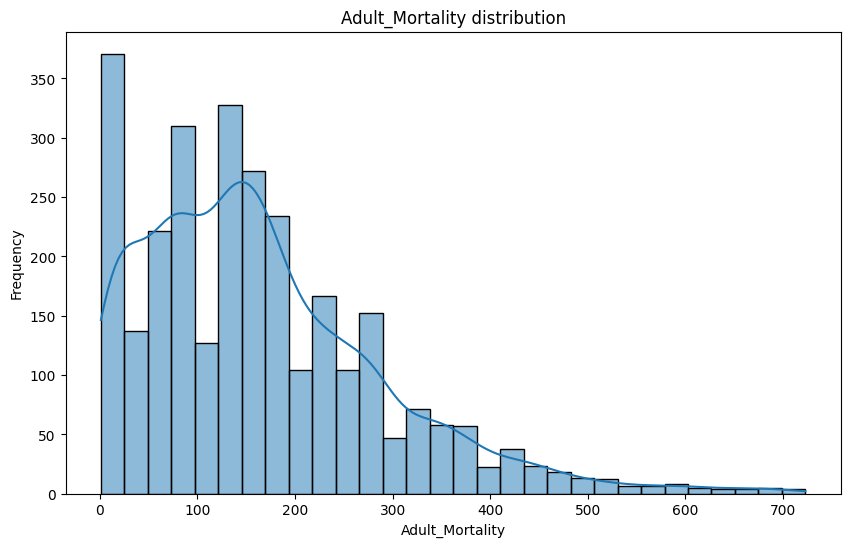

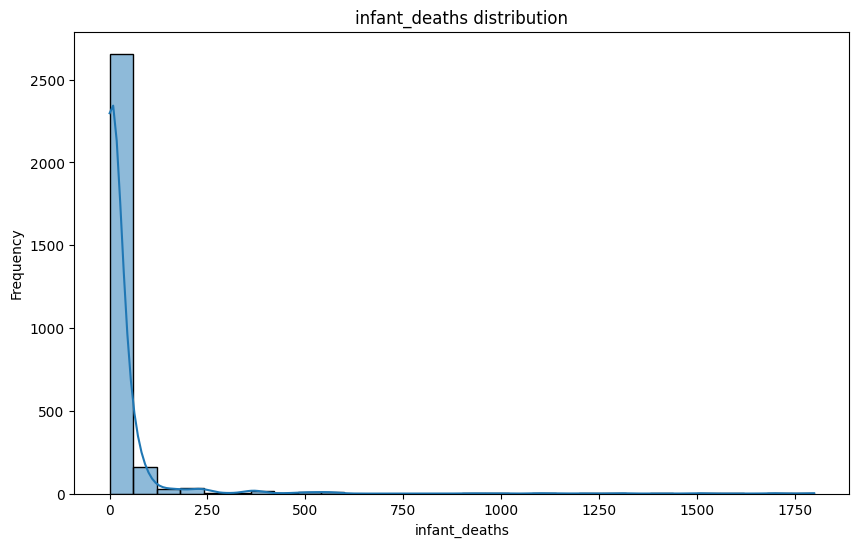

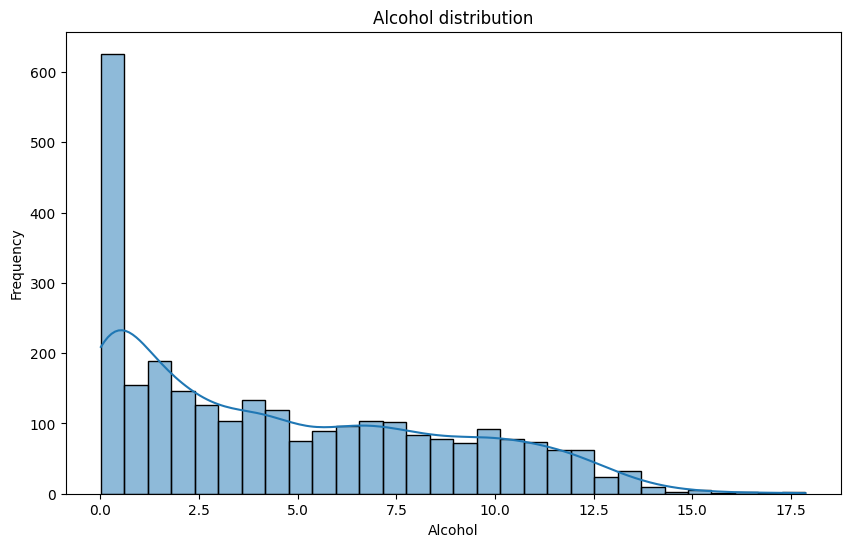

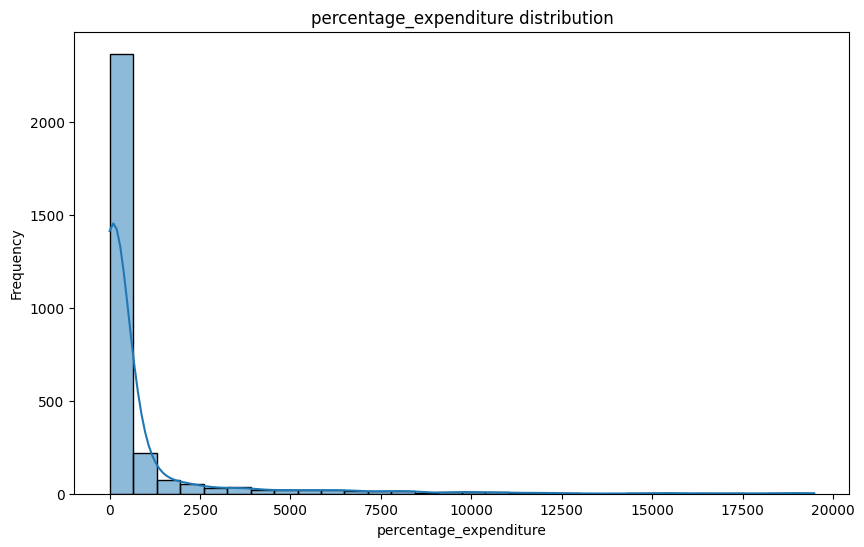

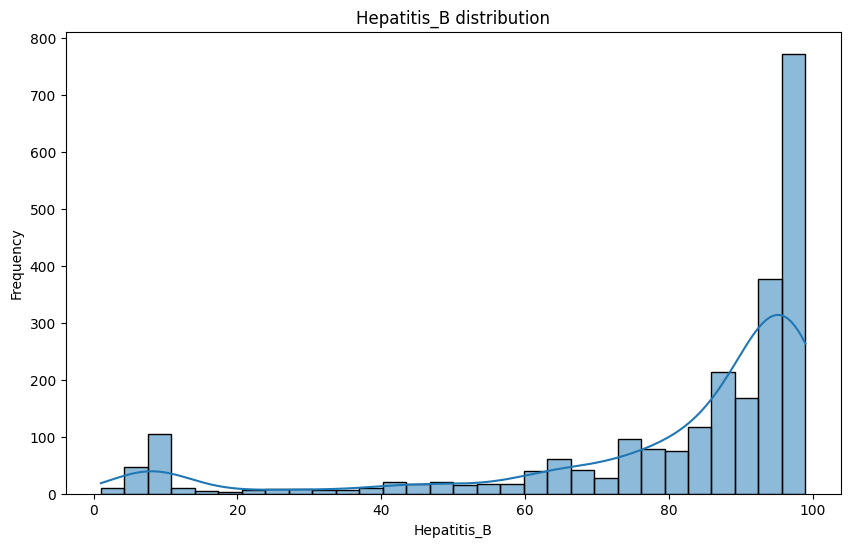

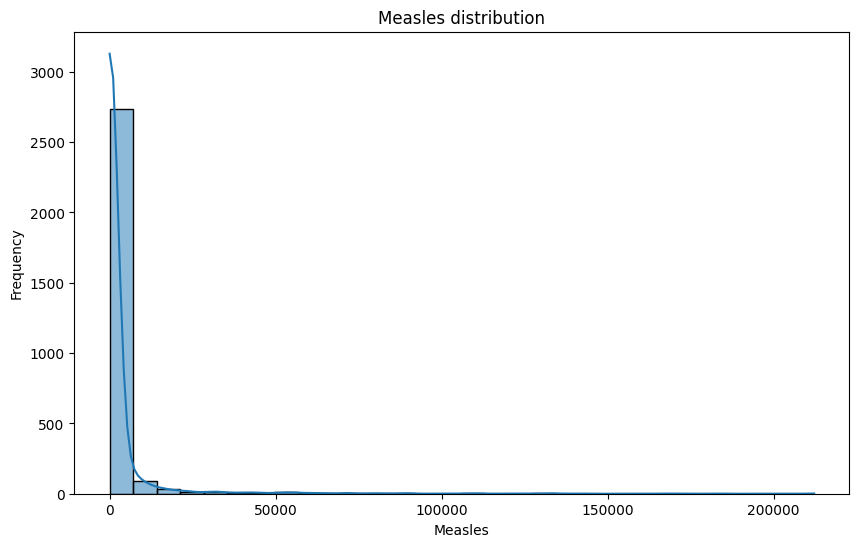

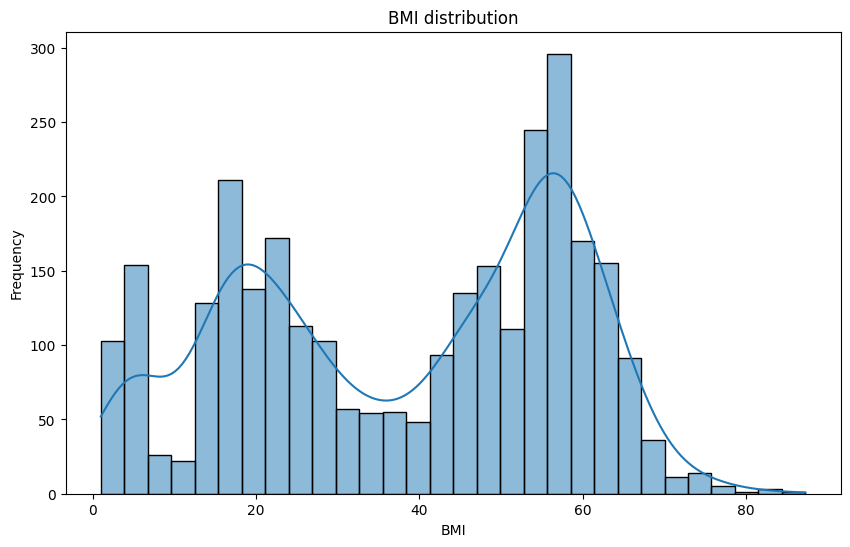

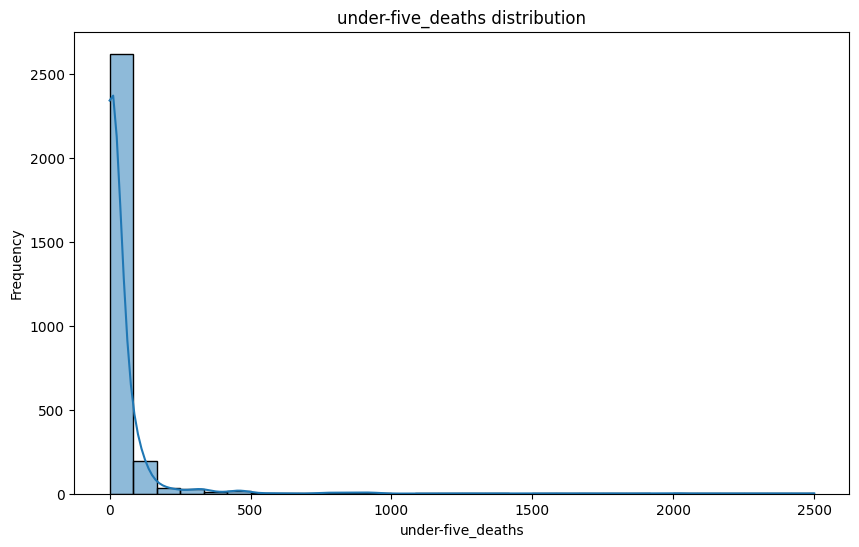

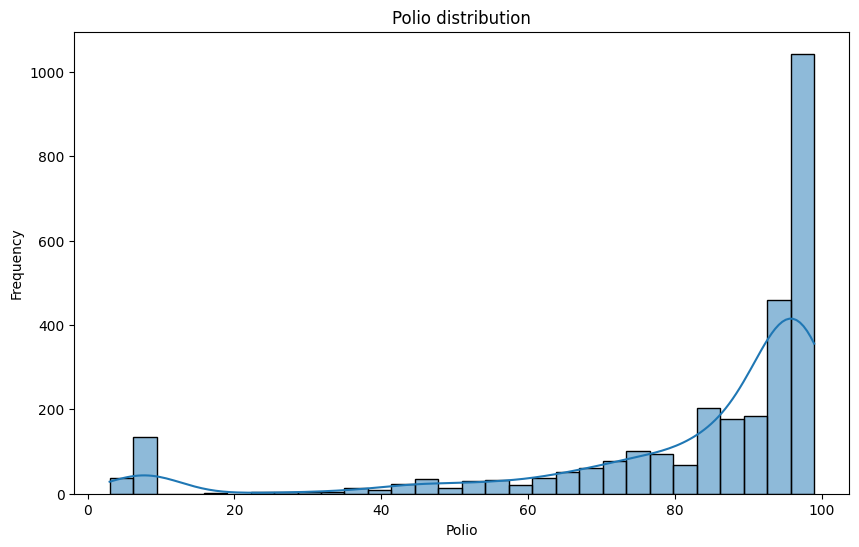

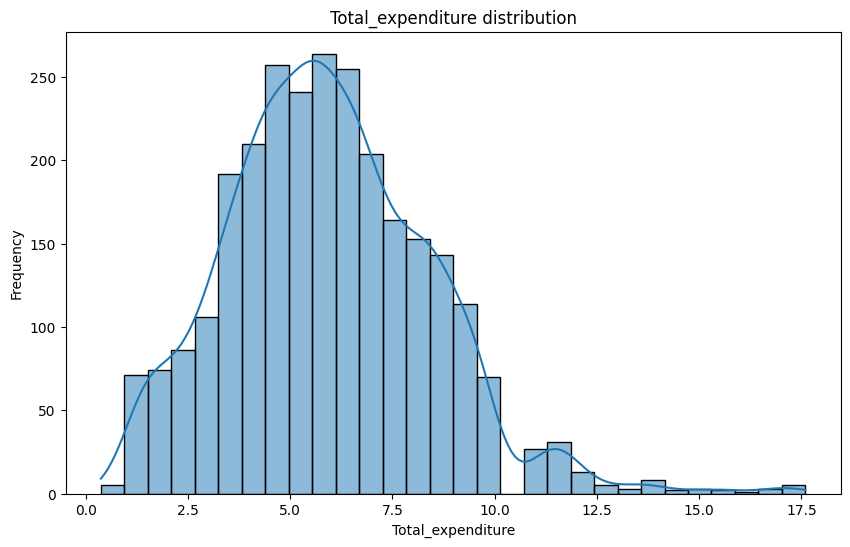

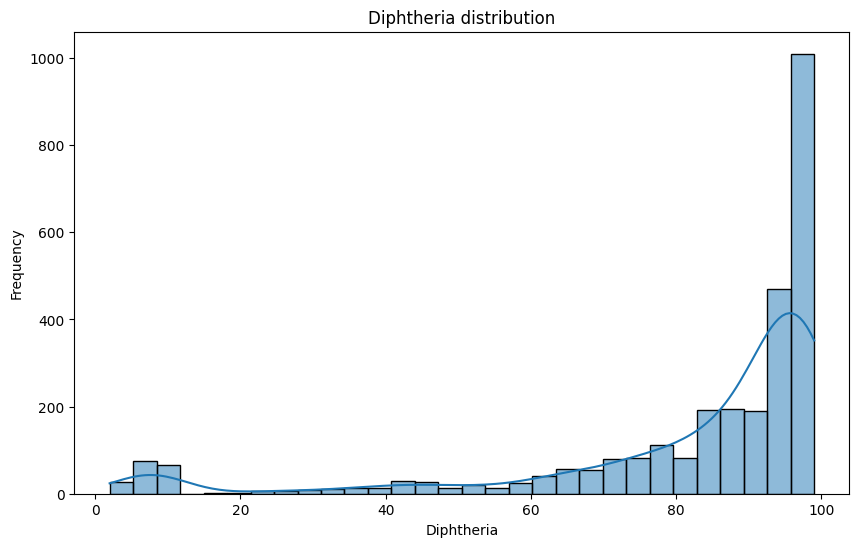

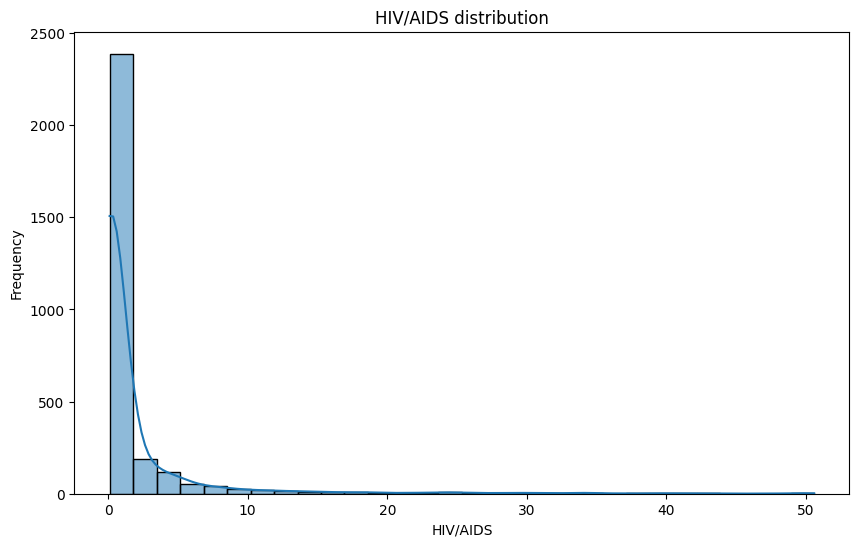

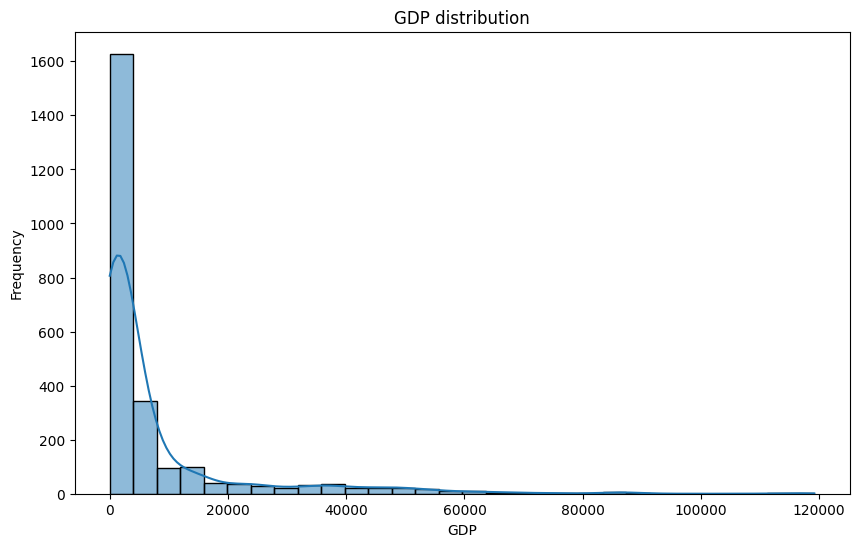

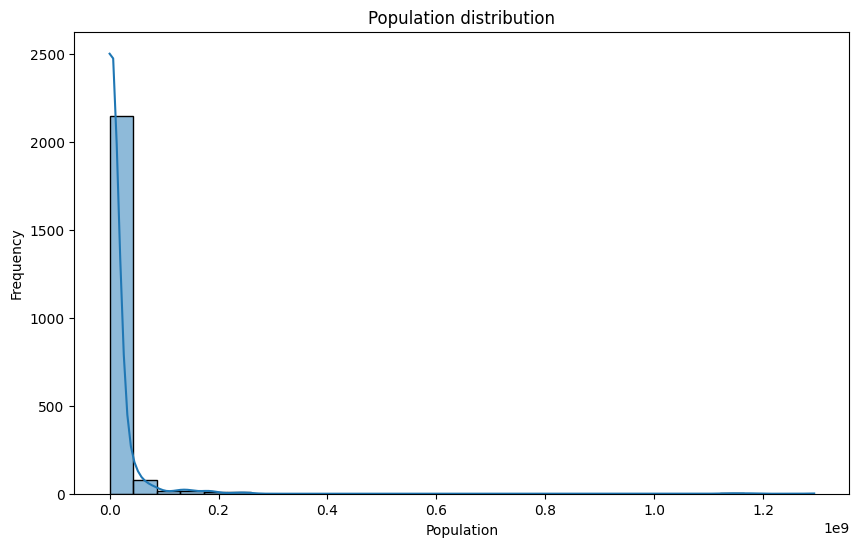

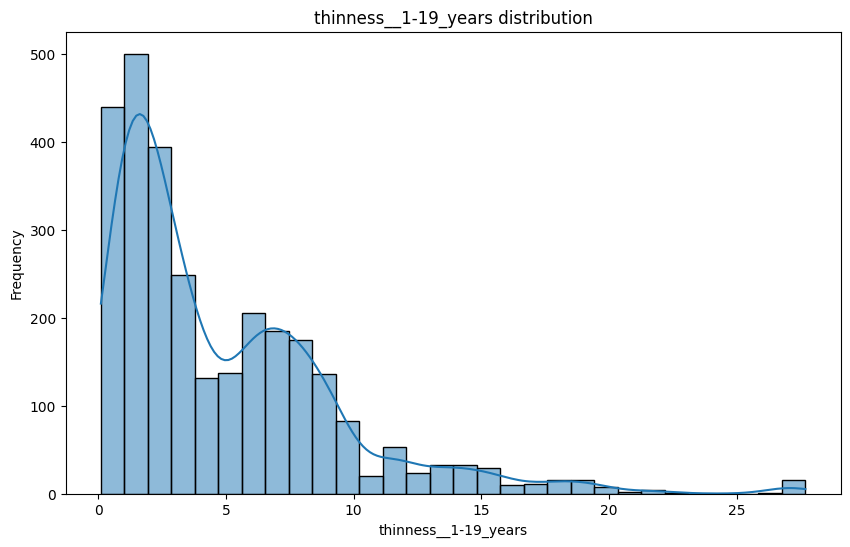

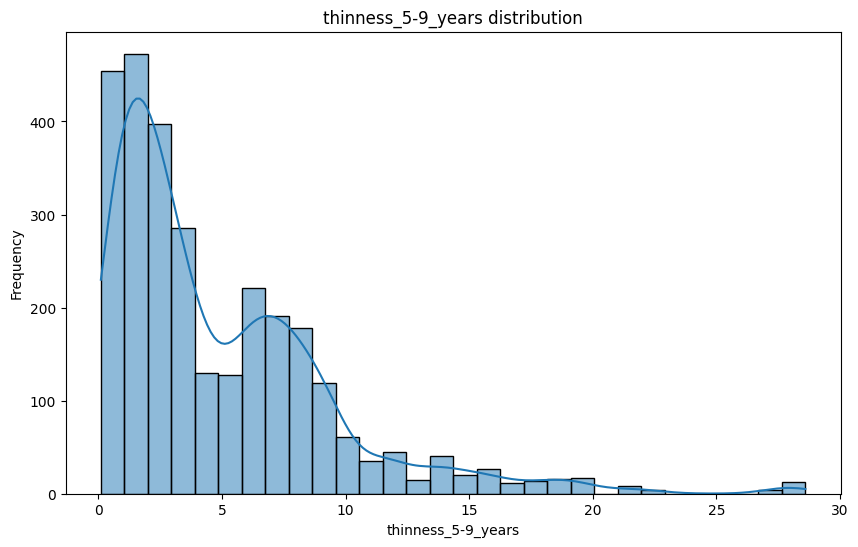

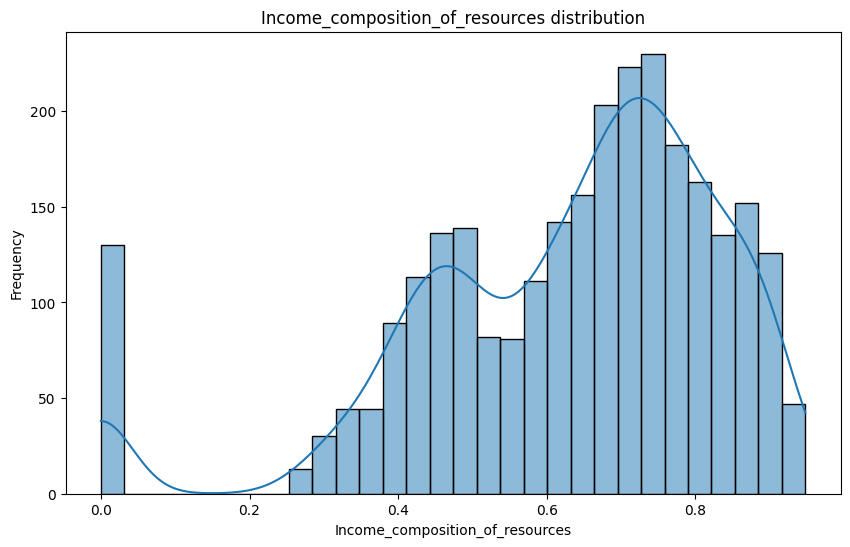

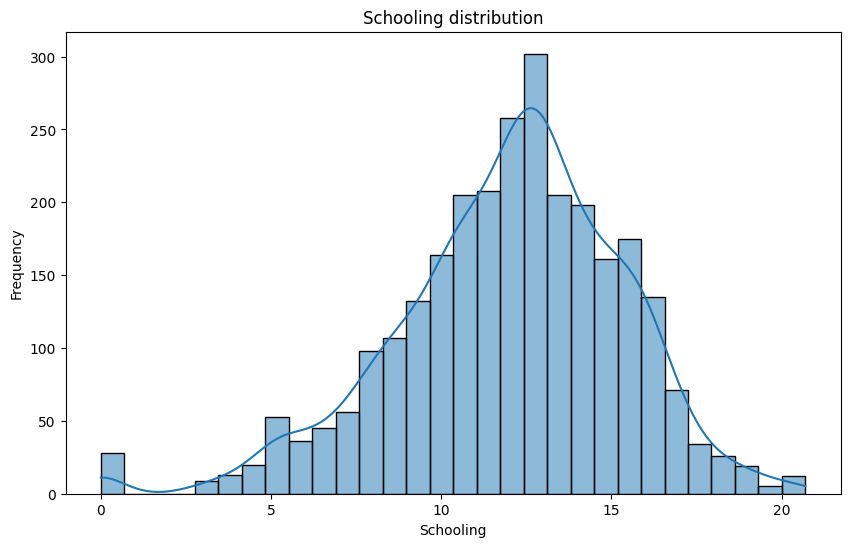

In [ ]:
for col in numeric_df:
    if col != "Life_expectancy" and col!="Year" and col != "Status":
        plt.figure(figsize = (10,6))
        sns.histplot(df[col], kde = True, bins = 30)
        plt.title(col + " distribution")
        plt.ylabel("Frequency")
        plt.xlabel(col)
        plt.show()

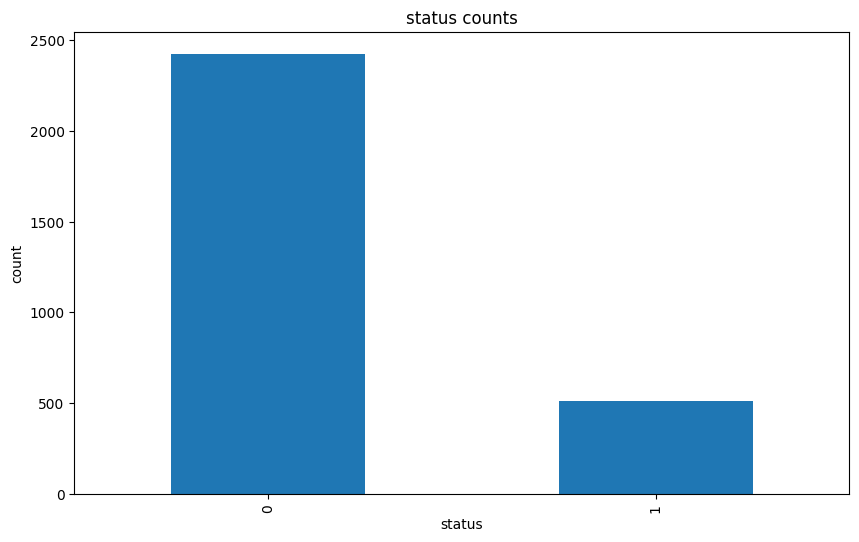

In [ ]:
plt.figure(figsize =(10,6))
df["Status"].value_counts().plot(kind="bar")
plt.title("status counts")
plt.xlabel("status")
plt.ylabel("count")
plt.show()

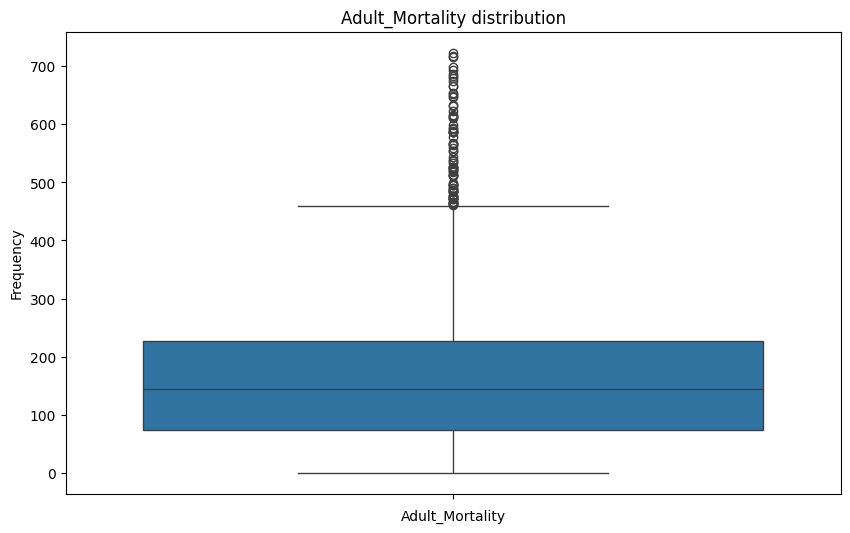

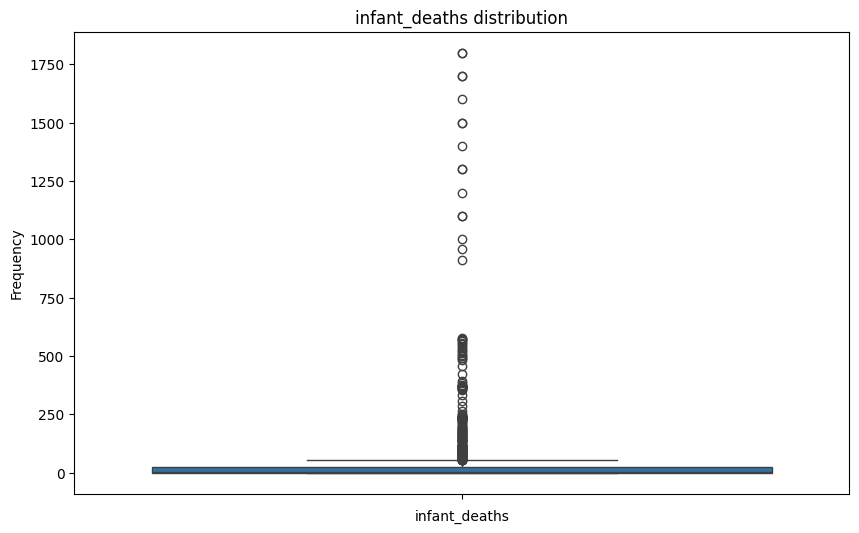

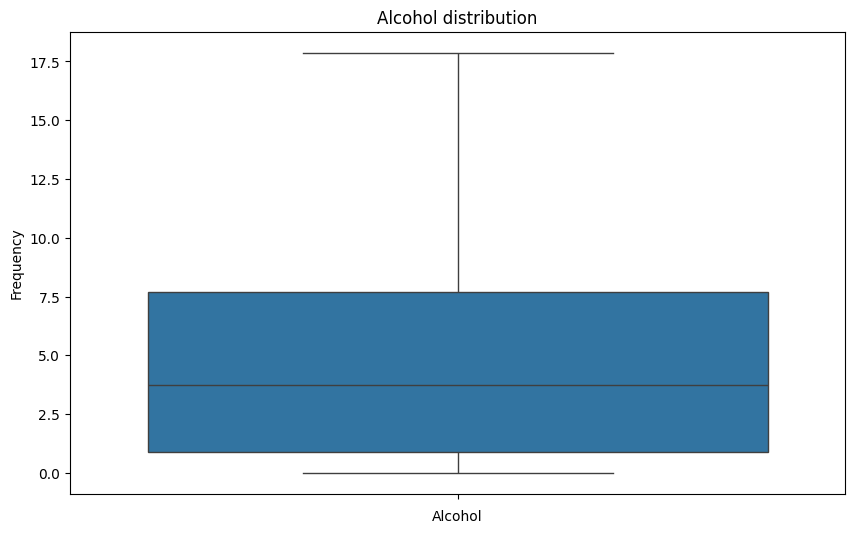

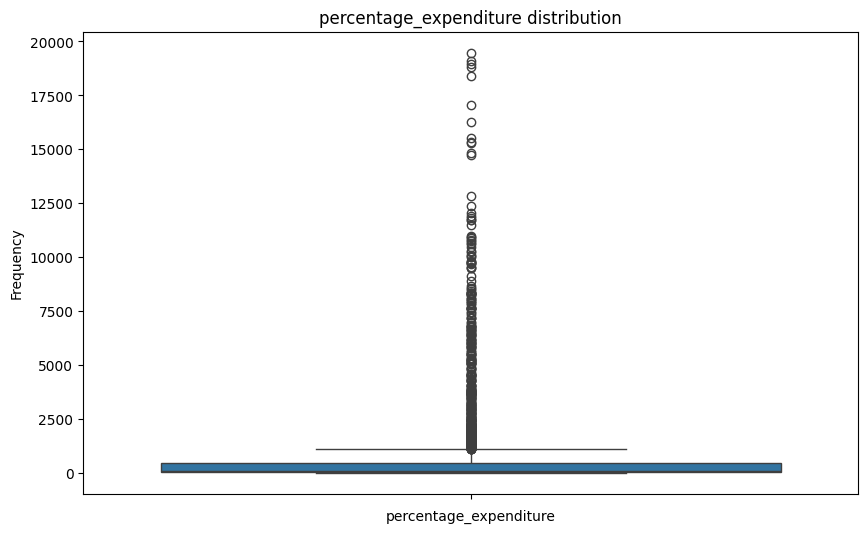

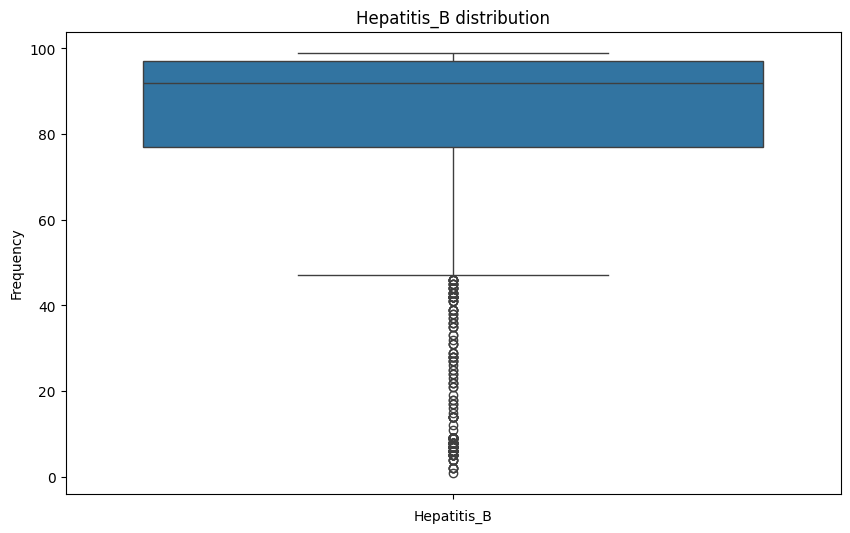

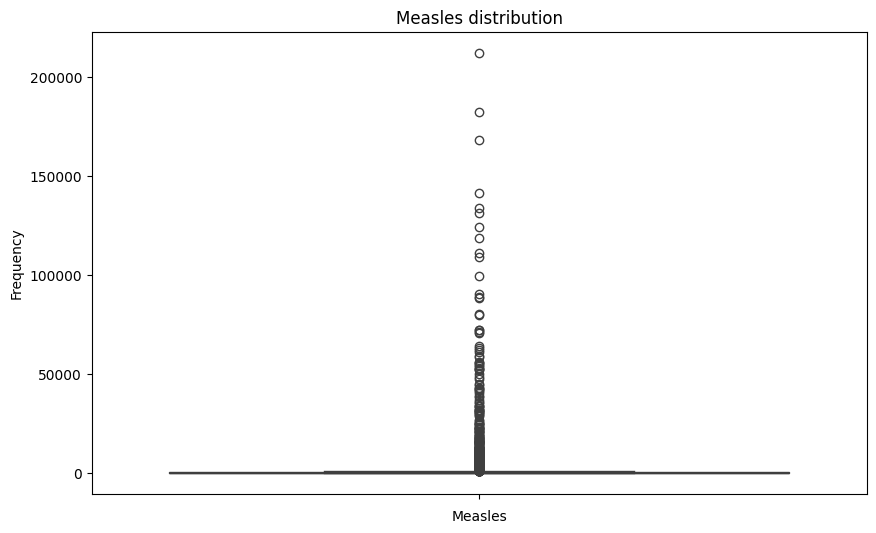

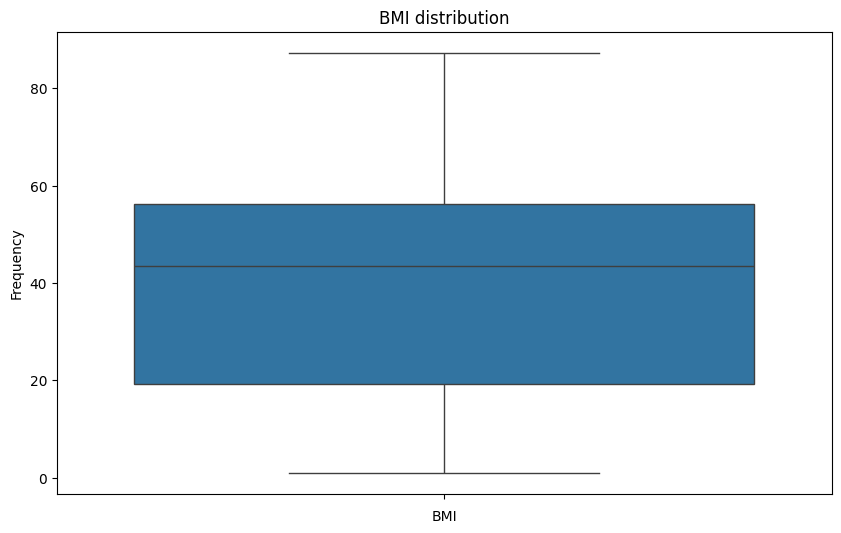

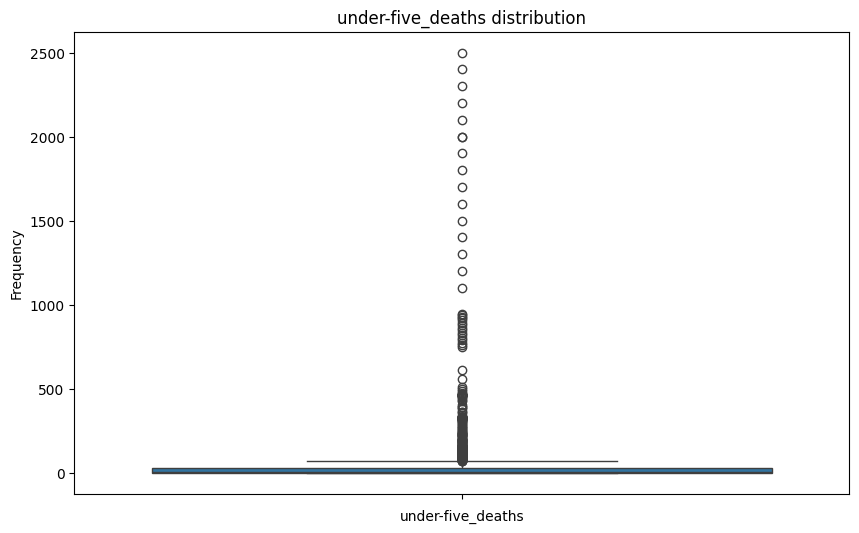

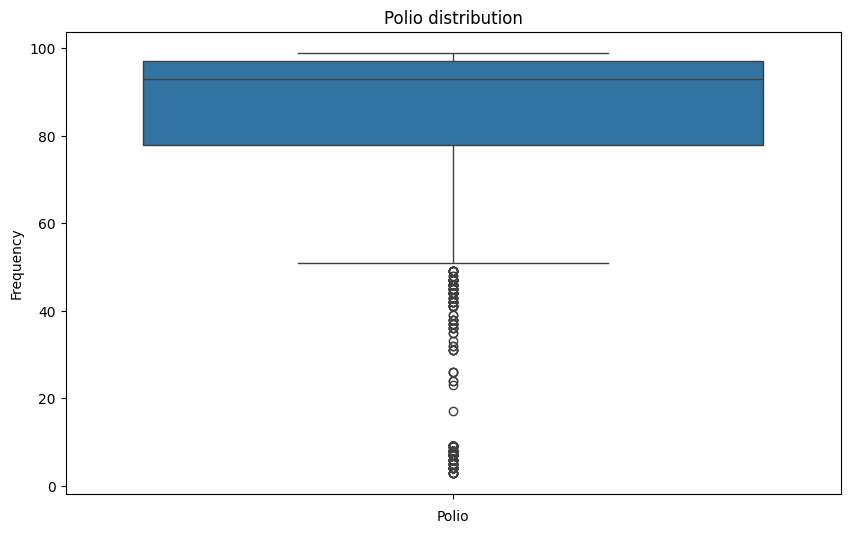

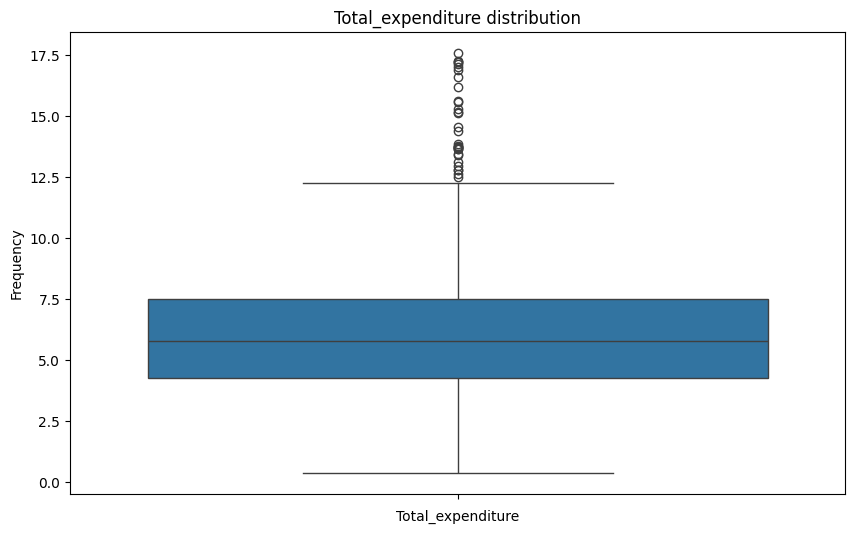

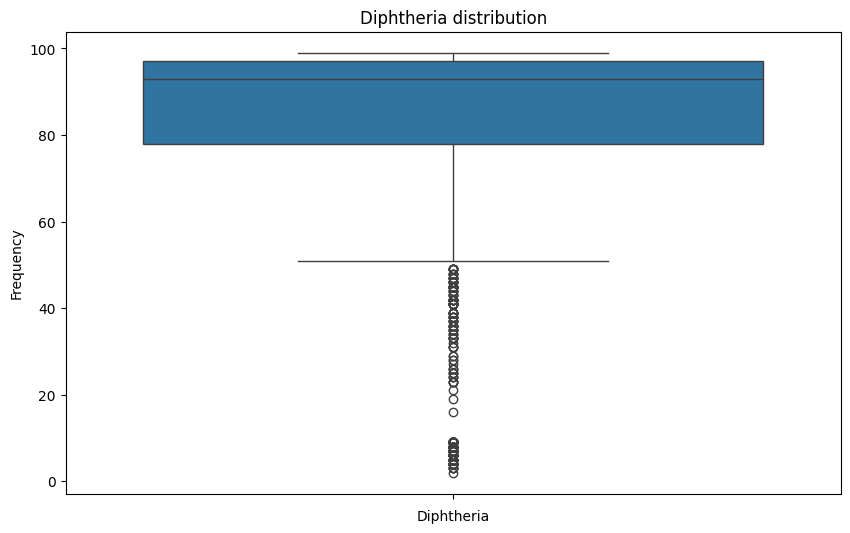

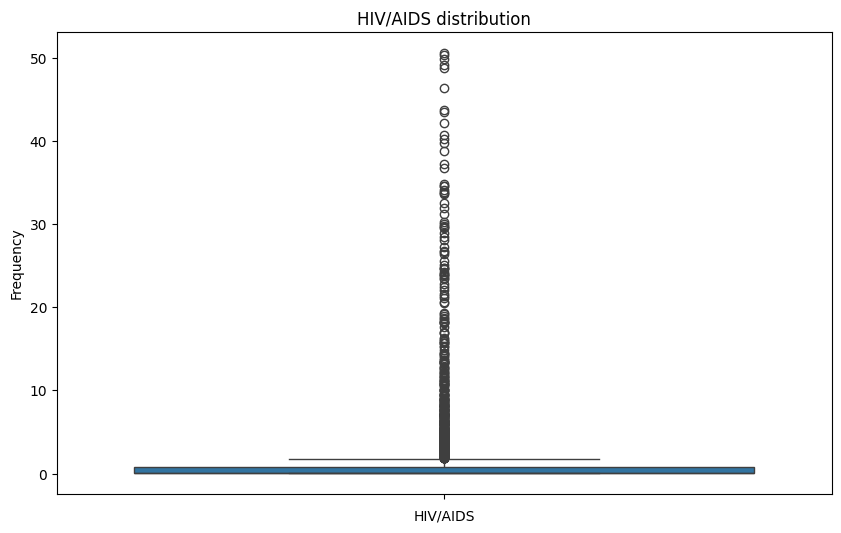

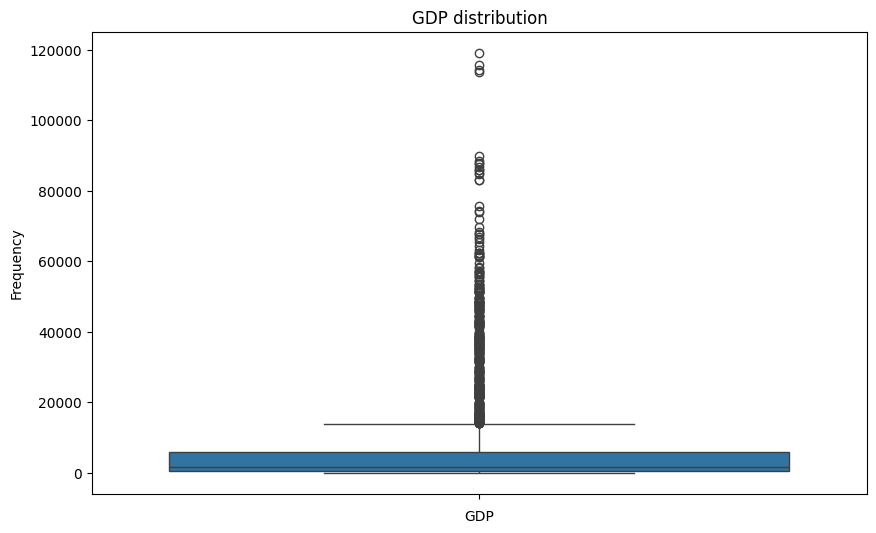

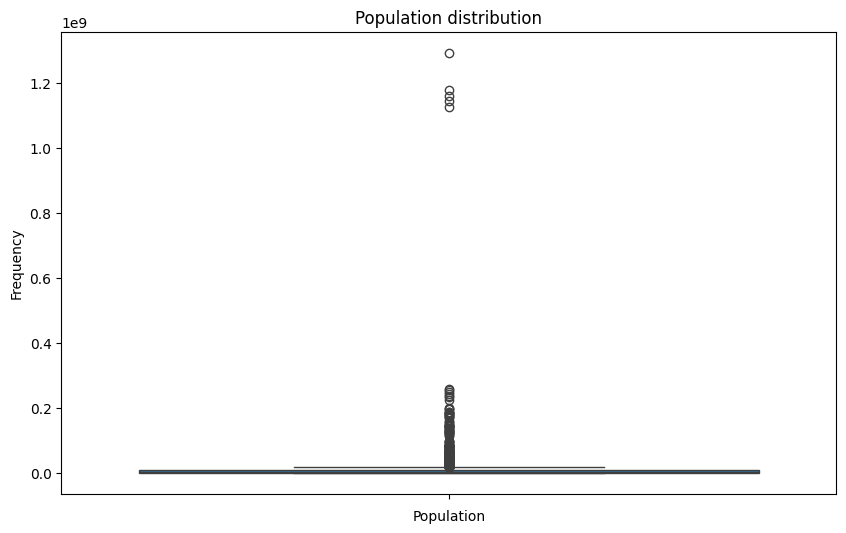

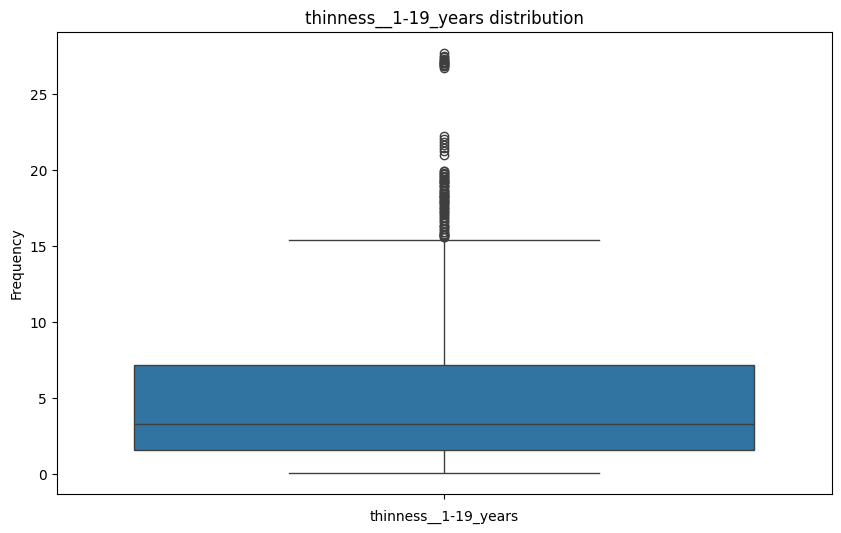

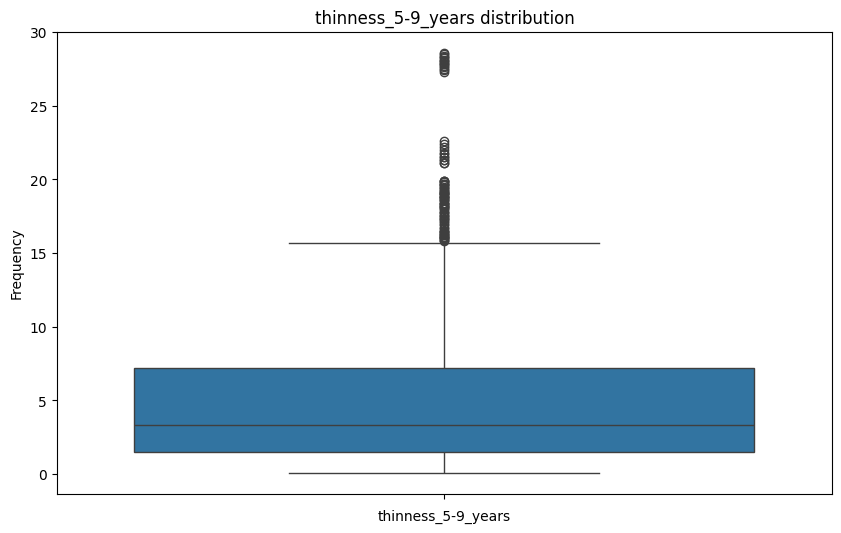

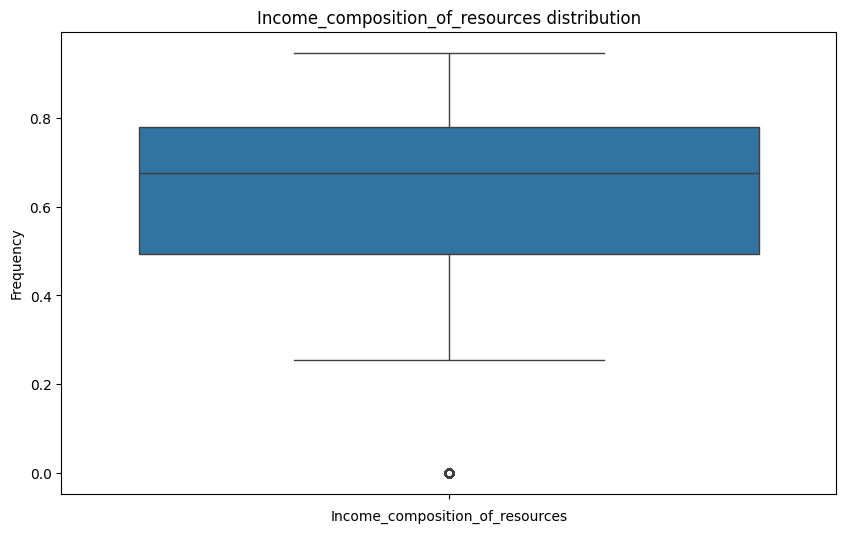

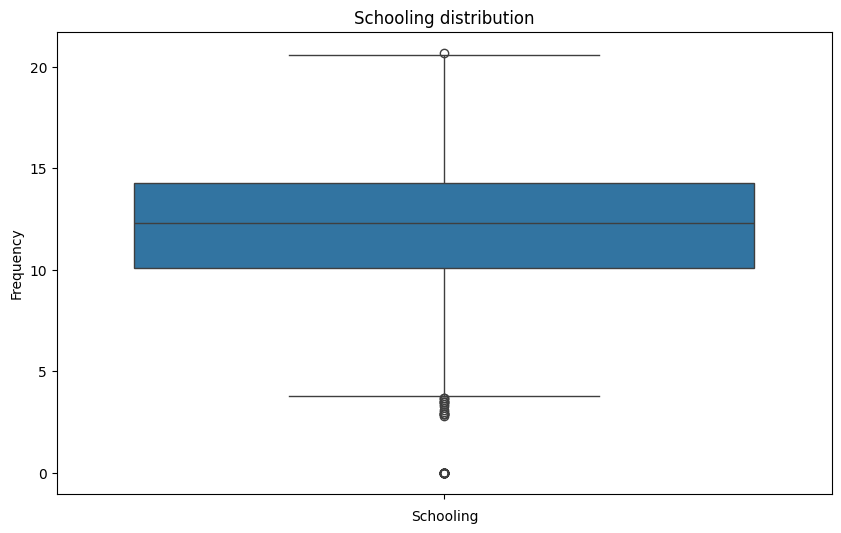

In [ ]:
for col in numeric_df:
    if col != "Life_expectancy" and col!="Year" and col != "Status":
        plt.figure(figsize = (10,6))
        sns.boxplot(df[col])
        plt.title(col + " distribution")
        plt.ylabel("Frequency")
        plt.xlabel(col)
        plt.show()

In [ ]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

""" Fill missing numeric values with median using simple imputer
The choice of replacing missing values with their respective median is as a result of most of our features being heavily skewed (mostly to the right), which would give a misleading interpretation to mean values. """

# Create imputer (median strategy)
imputer = SimpleImputer(strategy='median')

# Fit and transform numeric columns
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

# Confirm all missing values are handled
df.isnull().sum()

,0
Country,0
Year,0
Status,0
Life_expectancy,0
Adult_Mortality,0
infant_deaths,0
Alcohol,0
percentage_expenditure,0
Hepatitis_B,0
Measles,0


**Feature Selection and Target Definition**


The target variable for this project is Life_expectancy. All other relevant numeric variables, except Country, are used as predictors.

Country is excluded because it is a categorical identifier rather than a measurable predictive feature.

The VIF(Variance Inflation feature) for each feature is computed to check for indicators that can be problematic to predicting Life_expectancy.


In [ ]:
model_features = df.select_dtypes(include = ['number']).drop(columns = ["Life_expectancy", "Year"])
vif_results = pd.DataFrame()
vif_results["feature"] = model_features.columns
vif_results["VIF"] = [variance_inflation_factor(model_features.values, i) for i in range(model_features.shape[1])]

print(vif_results)

                            feature         VIF
0                            Status    2.235896
1                   Adult_Mortality    3.969252
2                     infant_deaths  183.739449
3                           Alcohol    4.315350
4            percentage_expenditure    6.564406
5                       Hepatitis_B   16.717484
6                           Measles    1.431812
7                               BMI    7.782288
8                 under-five_deaths  182.955768
9                             Polio   25.498512
10                Total_expenditure    7.753017
11                       Diphtheria   28.196837
12                         HIV/AIDS    1.580357
13                              GDP    7.444704
14                       Population    1.543672
15             thinness__1-19_years   19.111029
16               thinness_5-9_years   19.145462
17  Income_composition_of_resources   30.678110
18                        Schooling   43.706958


In [ ]:
# Drop infant_deaths and thinness_5-9 years

y = df["Life_expectancy"]
X = df.drop(columns = ["Life_expectancy", "Country", "thinness_5-9_years", "infant_deaths"])

X.head()

,Year,Status,Adult_Mortality,Alcohol,percentage_expenditure,Hepatitis_B,Measles,BMI,under-five_deaths,Polio,Total_expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness__1-19_years,Income_composition_of_resources,Schooling
0,2015.0,0.0,263.0,0.01,71.279624,65.0,1154.0,19.1,83.0,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,0.479,10.1
1,2014.0,0.0,271.0,0.01,73.523582,62.0,492.0,18.6,86.0,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,0.476,10.0
2,2013.0,0.0,268.0,0.01,73.219243,64.0,430.0,18.1,89.0,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,0.470,9.9
3,2012.0,0.0,272.0,0.01,78.184215,67.0,2787.0,17.6,93.0,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,0.463,9.8
4,2011.0,0.0,275.0,0.01,7.097109,68.0,3013.0,17.2,97.0,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,0.454,9.5


**Train Test Split**


To evaluate model performance properly, the dataset is divided into training and testing sets. The model is trained on 80 percent of the data and evaluated on the remaining 20 percent.

This helps measure how well the model generalizes to unseen data.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (2350, 18)
Testing set size: (588, 18)


**Feature Scaling for Linear Regression**


Linear Regression is sensitive to the scale of input variables. Since the dataset contains variables measured in different units, such as GDP, Population, and Alcohol consumption, feature scaling is applied.

Standardization transforms the data so that each feature has a mean of 0 and a standard deviation of 1. This improves model stability and ensures fair coefficient comparison.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Model 1 – Linear Regression**


Linear Regression is used as a baseline model to predict life expectancy. It assumes a linear relationship between the predictors and the target variable.

The model is trained on the scaled training data and evaluated using Mean Absolute Error, Root Mean Squared Error, and coefficient of determination(R squared) value.

In [ ]:
# Train model
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
# Coefficients for each feature(slope)
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

coefficients = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': lin_reg.coef_
})

# Intercept
intercept = lin_reg.intercept_

display(coefficients)
print(f"Intercept: {intercept}")

,Feature,Coefficient
0,Year,-0.030500
1,Status,0.627646
2,Adult_Mortality,-2.642565
3,Alcohol,0.081851
4,percentage_expenditure,0.138556
5,Hepatitis_B,-0.513693
6,Measles,-0.381061
7,BMI,0.837162
8,under-five_deaths,-0.253204
9,Polio,0.715687


Intercept: 69.2867659574468


In [ ]:
y_pred = lin_reg.predict(X_train_scaled)
results_df = pd.DataFrame({
    'Actual': y_train,
    'Predicted': y_pred
})

display(results_df.head(10))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


,Actual,Predicted
456,72.3,70.175438
462,73.0,64.076450
2172,74.6,72.804041
2667,74.9,76.967120
381,74.8,73.824463
847,53.5,57.442385
1987,59.6,60.346589
790,75.3,72.811346
1727,64.0,67.720088
2051,74.7,77.140349


In [ ]:
y_pred_test = lin_reg.predict(X_test_scaled)
results_test = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_test
})

display(results_test.head(10))

,Actual,Predicted
2546,73.7,66.875771
650,75.9,77.176064
1740,74.2,76.046409
177,76.8,78.383724
1377,51.9,47.228096
535,49.6,51.185368
2371,67.4,67.462899
2014,73.9,70.736720
321,77.2,74.621270
2493,55.0,54.330553


In [ ]:
MAE = mean_absolute_error(y_test, y_pred_test)
MAE = round(MAE, 2)
print(MAE)

2.95


In [ ]:
#percentage error
average_life_expectancy = df['Life_expectancy'].mean()
MAE_percentage_of_avg = (MAE / average_life_expectancy) * 100

print(round(MAE_percentage_of_avg, 2))

4.26


In [ ]:
# Calculate R-squared for the training set
r2_train = r2_score(y_train, y_pred)

# Calculate R-squared for the test set
r2_test = r2_score(y_test, y_pred_test)

print(round(r2_train, 2))
print(round(r2_test, 2))

0.81
0.81


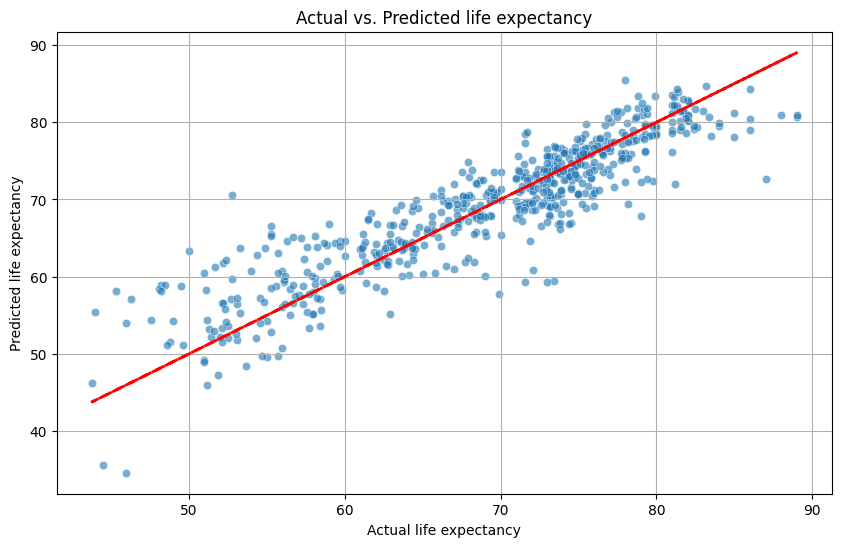

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.6)
plt.plot(y_test, y_test, 'r--', lw=2)
plt.xlabel('Actual life expectancy')
plt.ylabel('Predicted life expectancy')
plt.title('Actual vs. Predicted life expectancy')
plt.grid(True)
plt.show()

**Linear Regression Interpretation**

The Linear Regression model achieved an R squared value of approximately 0.81, indicating that the model explains about 82 percent of the variation in life expectancy.

The Mean Absolute Error of approximately 2.95 suggests that predictions deviate from actual values by about 3 years on average.

Overall, the baseline model demonstrates strong predictive performance, suggesting that the selected socioeconomic and health indicators are meaningful predictors of life expectancy.

**Model 2: Random Forest Regression**


Random Forest is a tree based ensemble model that can capture nonlinear relationships and complex interactions between variables.

Unlike Linear Regression, Random Forest does not require feature scaling.

In [ ]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

Random Forest Results
MAE: 1.1799315579917278
RMSE: 1.7170655422758403
R2: 0.9659812656575346


In [ ]:
#percentage error for Random Forest
average_life_expectancy = df['Life_expectancy'].mean()
MAE_percentage_of_avg_rf = (mae_rf / average_life_expectancy) * 100

print(round(MAE_percentage_of_avg_rf, 2))

1.7


Text(0.5, 1.0, 'Residuals vs. Actual life expectancy')

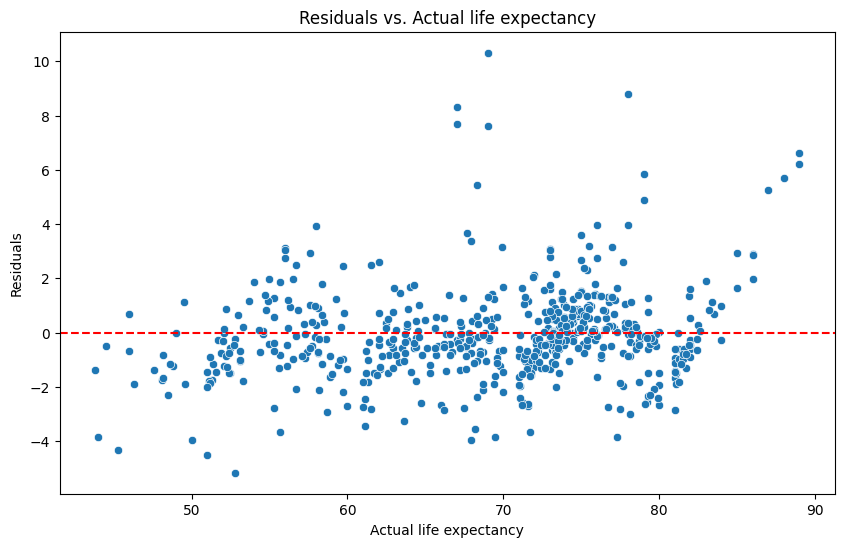

In [ ]:
residuals = y_test - y_pred_rf

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Actual life expectancy')
plt.ylabel('Residuals')
plt.title('Residuals vs. Actual life expectancy')

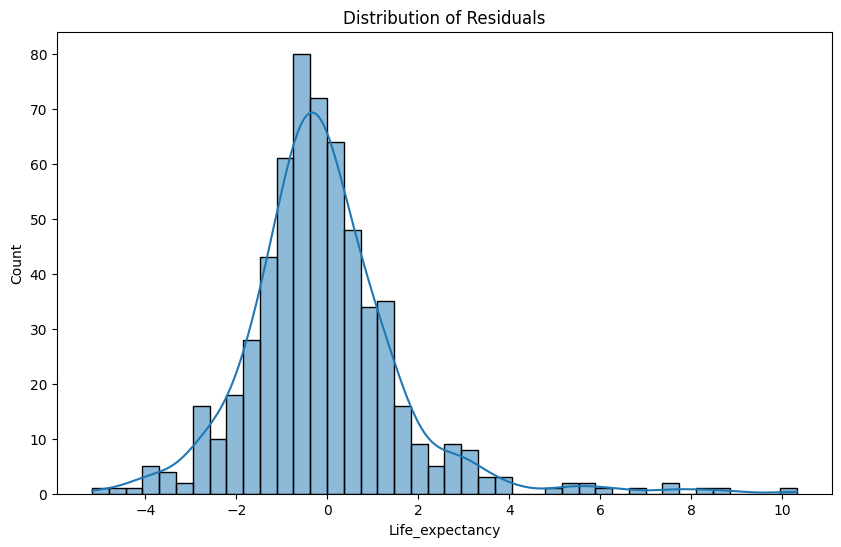

In [ ]:
plt.figure(figsize =(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.show()

The residuals are approximately symmetric and centred around zero, indicating that the normality assumptions are reasonable satistified.

**Random Forest Interpretation**

The Random Forest model achieved an R squared value of approximately 0.97, indicating that it explains about 96 percent of the variation in life expectancy.

The Mean Absolute Error decreased significantly to approximately 1.18 years, showing a substantial improvement over the Linear Regression model.

This suggests that nonlinear relationships and complex interactions among socioeconomic and health indicators play an important role in predicting life expectancy.

Overall, Random Forest outperforms Linear Regression in predictive accuracy for this dataset.

**Feature Importance Analysis**


To understand which variables contribute most to predicting life expectancy, feature importance is extracted from the Random Forest model.

This helps identify the most influential socioeconomic and health indicators.

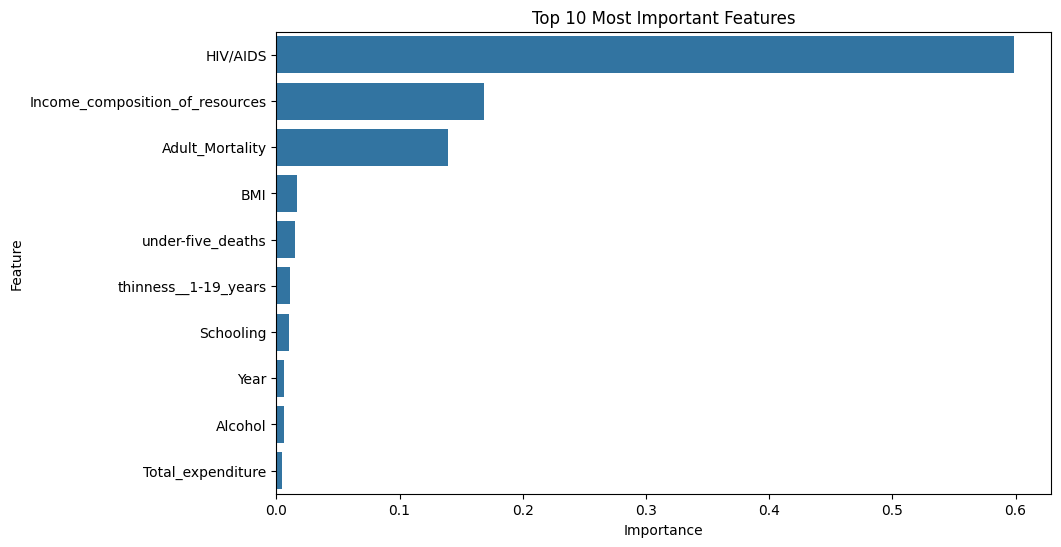

,Feature,Importance
12,HIV/AIDS,0.599148
16,Income_composition_of_resources,0.168884
2,Adult_Mortality,0.138913
7,BMI,0.017086
8,under-five_deaths,0.015477
15,thinness__1-19_years,0.011129
17,Schooling,0.010354
0,Year,0.006280
3,Alcohol,0.005999
10,Total_expenditure,0.004470


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance", ascending=False
)

plt.figure(figsize=(10,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)
plt.title("Top 10 Most Important Features")
plt.show()

feature_importance.head(10)

**Feature Importance Interpretation**

The Random Forest model identifies HIV/AIDS as the most influential predictor of life expectancy. This suggests that disease prevalence has a substantial impact on national life expectancy levels.

Income_composition_of_resources is the second most important feature, indicating that economic development and resource distribution significantly influence longevity.

Adult_Mortality also ranks highly, reinforcing the strong relationship between mortality rates and life expectancy.

These findings align with public health and economic theory, demonstrating that both disease burden and socioeconomic development are critical determinants of life expectancy.

**Model Comparison Summary**


The Random Forest model significantly outperformed Linear Regression in predictive accuracy. While Linear Regression explained approximately 82 percent of the variation in life expectancy, Random Forest increased explanatory power to approximately 96 percent.

The reduction in Mean Absolute Error from approximately 2.95 years to 1.18 years demonstrates the advantage of modeling nonlinear relationships in complex socioeconomic data.

Overall, Random Forest provides a more accurate and robust predictive model for life expectancy in this dataset.

**Conclusion**

This project demonstrates that life expectancy is strongly influenced by both health indicators and socioeconomic factors. Disease prevalence, particularly HIV/AIDS, plays a dominant role, while economic development and mortality rates are also critical drivers.

The strong performance of the Random Forest model highlights the importance of nonlinear interactions in real world data.

These findings emphasize the need for integrated public health and economic development policies to improve life expectancy outcomes globally.

## Columns Description

- **Country**: Name of the country where the data was recorded.
- **Year**: The year the data was collected.
- **Status**: Classification of the country as Developed or Developing.
- **Life expectancy**: Average number of years a newborn is expected to live.
- **Adult Mortality**: Probability (per 1000 population) that a person aged 15–60 will die.
- **infant deaths**: Number of infant deaths (under 1 year) per 1000 population.
- **Alcohol**: Per capita alcohol consumption (litres of pure alcohol) among people aged 15+.
- **percentage expenditure**: Health expenditure as a percentage of GDP per capita.
- **Hepatitis B**: Percentage of 1-year-olds vaccinated against Hepatitis B.
- **Measles**: Number of reported measles cases per 1000 population.
- **BMI**: Average Body Mass Index of the population.
- **under-five deaths**: Number of deaths of children under age 5 per 1000 population.
- **Polio**: Percentage of 1-year-olds vaccinated against Polio (Pol3).
- **Total expenditure**: Government health expenditure as a percentage of total government spending.
- **Diphtheria**: Percentage of 1-year-olds vaccinated against DTP3 (Diphtheria, Tetanus, Pertussis).
- **HIV/AIDS**: Deaths due to HIV/AIDS per 1000 live births (ages 0–4).
- **GDP**: Gross Domestic Product per capita (in USD).
- **Population**: Total population of the country.
- **thinness 1-19 years**: Percentage of children and adolescents (ages 10–19) who are underweight.
- **thinness 5-9 years**: Percentage of children (ages 5–9) who are underweight.
- **Income composition of resources**: Human Development Index (HDI) income component (range 0 to 1).
- **Schooling**: Average number of years of schooling completed.

**NAMES, EMAIL AND GITHUB REPOSITORY**

1. Adeniji Mayowa
youngkingmichael01@gmail.com
https://github.com/Big-mayor/TS_Academy_Capstone_Project

2. Joseph Odili Alex
Joecalex309@gmail.com
https://github.com/heis3nberg9/TS_Academy_Capstone_Project

3. Obichukwu Adaeze Suzan
   suzy4realus@gmail.com
   https://github.com/repos
   https://github.com/Adaezeobichukwu?tab=repositories

4. Akinseye Daniel Jesutimileyin
   akinseyedaniel22960@gmail.com
   https://github.com/LIMITLESS042/TS-ACADEMY-CAPSTONE-PROJECT-18.git

5. Eniola Abimbola
   jeatie2@gmail.com
   https://github.com/Jeatiejade/TS_Academy_Capstone_Project

6. Solomon Ojukotimi
   solomonojukotimi@gmail.com
  https://github.com/Solomon-Ojukotimi/TS-ACADEMY-CAPSTONE-PROJECT

7. Abraham Emenuvwe
   abrahamemenuvwe38@gmail.com
    https://github.com/Timon8726/TS-ACADEMY-CAPSTONE-PROJECT

8. Inoghie David Ebunoluwa
   davidinoghie@gmail.com
   https://github.com/DavidZeGreat/TS_Academy_Capstone_Project_Group_18

9. Caleb Kazayet Kadon
   Kazayet1@gmail.com
   https://github.com/kazayet12/Capstone-Project---TS-Academy-Predicting-Life-Expectancy-Using-Socioeconomic-and-Health-Indicators-

10. Azeez Adekunle Ogunsina
    ogunsina.azeez@gmail.com
    https://github.com/AzeezAdekunle/

11. Issa Hamidat Olamide
    issahermeedah@gmail.com
    https://gi7thub.com/Hermeedah/TS-Academy-capstone-project

12. Nnamdi Kelvin Etumnu
    Etumnukelvin@gmail.com
    https://github.com/Jammijuix/TS-Academy-Capstone-Projects-Group-18.git

13. Omitogun Joy Olamide
    hephzibahjoy01@gmail.com
    https://github.com/joyce767/TS_Capstone_Project-.git

